<a href="https://colab.research.google.com/github/konishogu/DeepLearning/blob/main/EVALUACION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



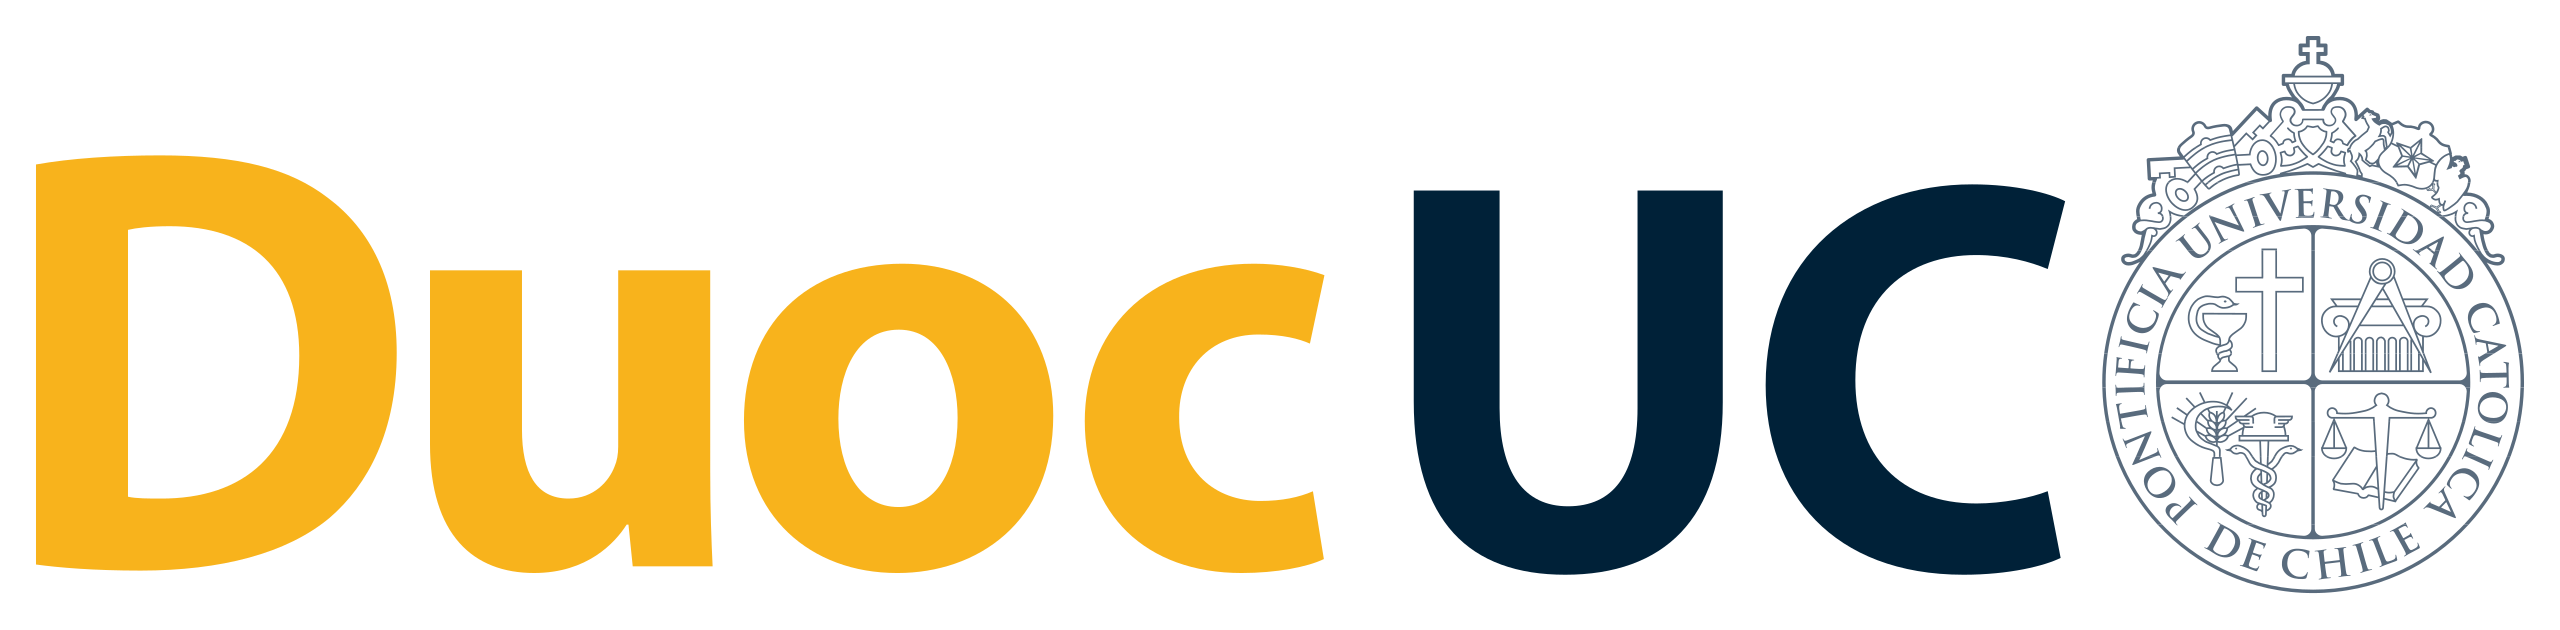



---
**Autores:**

- Matias Ignacio Wastavino Gonzalez
- Luis Rodrigo Nicolas Mendez Lehner
- Rodrigo Antonio Carcamo Rojas
- Matias Ignacio Molina Sepulveda
- Alejandra Ignacia Riquelme Velásquez

**Docente:** Marcelo Alejandro Tapia Contreras Tapia Contreras

**Asignatura:** Deep learning

**Sección:** 003D

**Institución:** Duoc UC - Sede Melipilla

**Fecha de entrega:** 24 de Abril de 2026

---

## **Introducción**
En el presente trabajo se desarrolla un modelo de Deep Learning basado en una red neuronal multicapa (MLP), con el objetivo de resolver un problema de clasificación de imágenes. Para ello, se utiliza el dataset Fashion-MNIST, el cual contiene imágenes en escala de grises correspondientes a distintas prendas de vestir, tales como camisetas, pantalones, zapatos y bolsos.

Este conjunto de datos está compuesto por imágenes de 28x28 píxeles distribuidas en 10 clases, lo que lo convierte en un problema de clasificación multiclase. Cada imagen representa una prenda específica, y el objetivo del modelo es identificar correctamente la categoría a la que pertenece.

El propósito principal es diseñar, entrenar y evaluar un modelo de red neuronal, aplicando técnicas fundamentales como el preprocesamiento de datos, la selección de funciones de activación, la optimización de hiperparámetros y la evaluación mediante métricas como accuracy, precision, recall y F1-score.

Adicionalmente, se realizan experimentos controlados para analizar el impacto de distintos parámetros, como la tasa de aprendizaje, el número de épocas y el tamaño del batch, con el fin de mejorar el rendimiento del modelo y comprender su comportamiento durante el entrenamiento.



# **Fase 1: Preprocesamiento de datos**

## **1.1. Cargar los datos**

### **1.1.1. Importaciones necesarias**

En esta sección se han definido las herramientas fundamentales para el desarrollo de la red neuronal artificial (MLP).

In [ ]:
# Permite trabajar con redes neuronales
import tensorflow as tf

# Permite visualizar graficos e imágenes
import matplotlib.pyplot as plt

# Permite construir y entrenar modelos
from tensorflow import keras

# Permite manejar y manipular arreglos numéricos y matrices
import numpy as np

# Permite evaluar el rendimiento del modelo mediante métricas de clasificación
from sklearn.metrics import classification_report, confusion_matrix

# Permite crear visualizaciones
import seaborn as sns

1. Tensorflow como la base que permite a la red neuronal aprender a partir de los datos, ya que se encarga de realizar los cáculos necesarios para ajustar los parámetros del modelo (pesos y bias) y mejorar sus predicciones con el tiempo. Sin esta librería, el entrenamiento sería mucho más complejo, ya que habría que implementar manualmente todos estos procesos.

2. Matplotlib para visualizar tanto los datos como los resultados del modelo. Gracias a esta herramienta es posible representar imágenes y gráficos de forma clara, lo que facilita entender el comportamiento del entrenamiento y detectar posibles problemas. Sin esto, el análisis se limitaría a valores numéricos, dificultando la interpretación.

3. Keras para reducir la complejidad de desarrollo, ofreciendo funciones listas para definir, entrenar y evaluar el modelo de manera simple y estructurada, permitiendo enfocar el trabajo en el diseño del modelo y el análisis de resultados, en lugar de implementar cada componente desde cero.

4. Numpy para transformar las imágenes en estructuras matemáticas que el modelo pueda entender. Esta herramienta nos permite limpiar, organizar y normalizar los píxeles del dataset de forma rápida. Sin este elemento, no podríamos entregarle los datos a la red neuronal en el formato adecuado para que aprenda.

5. Classification Report para desglosar el rendimiento del modelo por cada tipo de prenda. Esta herramienta permite analizar métricas de precisión, sensibilidad y puntuación de forma individual para cada una de las 10 categorías del dataset. Sin este informe, solo conoceríamos el promedio general de aciertos, ocultando si el modelo tiene dificultades específicas con prendas visualmente similares.

6. Confusion Matrix para identificar visualmente los errores de clasificación del modelo. Gracias a esto, es posible detectar qué categorías se están confundiendo entre sí. Sin este mapa de errores, no podríamos entender la naturaleza de las equivocaciones ni ajustar el modelo para mejorar su capacidad.

7. Seaborn para elevar la calidad visual de las métricas de evaluación, permitiendo generar mapas de calor que hacen la matriz de confusión mucho más interpretable. Gracias a esto, los errores del modelo no se ven solo como números en una tabla, sino como gradientes de color que resaltan inmediatamente dónde están los fallos más críticos.

### **1.1.2. Versionado**

Al ejecutar el código se obtiene la versión de TensorFlow instalada en el entorno, permitiendo asegurar que las funciones a utilizar sean compatibles y funcionen correctamente.

In [ ]:
# Verificar versión de TensorFlow
print(f"{tf.__version__}")

2.19.0


### **1.1.3. Dataset**

En este apartado, el código permite acceder al dataset Fashion-MNIST desde Keras y cargarlo en el entorno de trabajo. Este conjunto de datos se encuentra previamente dividido en dos partes: un conjunto de entrenamiento, utilizado para que la red neuronal aprenda patrones, y un conjunto de prueba, que se emplea para evaluar el rendimiento del modelo con datos que no ha visto anteriormente.

In [ ]:
# Acceder al dataset
fashion_mnist = keras.datasets.fashion_mnist

# Separar en datos de entrenamiento y prueba
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Verificar la forma de los datos cargados
print(f"------------------------------------------------")
print(f"Imágenes de entrenamiento: {X_train_full.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de entrenamiento: {y_train_full.shape}")
print(f"------------------------------------------------")
print(f"Imágenes de prueba: {X_test.shape}")
print(f"------------------------------------------------")

------------------------------------------------
Imágenes de entrenamiento: (60000, 28, 28)
------------------------------------------------
Etiquetas de entrenamiento: (60000,)
------------------------------------------------
Imágenes de prueba: (10000, 28, 28)
------------------------------------------------


**CONCLUSIONES:**

- Mediante el uso de .shape, se imprime la forma de cada conjunto de datos. Esto permite verificar que la carga se realizó correctamente, conocer la cantidad de imágenes disponibles y entender cómo están organizadas.

- En total, se cargan 70.000 imágenes, de las cuales 60.000 corresponden al entrenamiento y 10.000 a la prueba. Cada imagen está representada como una matriz de 28 x 28 píxeles y se almacena en las variables "x", mientras que sus respectivas etiquetas, es decir, la categoría de la prenda se guardan en las variables "y".

- El nombre X_train_full se utiliza para indicar que este es el conjunto de entrenamiento completo, el cual posteriormente será dividido para generar un subconjunto de validación en la siguiente fase.

### **1.1.4. Lista de clases**

In [ ]:
# Definir los nombres de las categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

**JUSTIFICACIÓN DE DECISIÓN:**

- Al cargar el dataset Fashion-MNIST, las etiquetas y_train_full no están representadas como nombres de prendas (ej: “zapato” o “camisa”), sino como valores numéricos enteros entre 0 y 9. Para el modelo, estos números son suficientes, ya que trabaja con estas representaciones, sin embargo, para ser interpretados no entregan un significado claro por sí solos. Por esta razón, se define la lista “class_names”, que actúa como un diccionario entre cada valor numérico y su categoría correspondiente. Cada posición de la lista representa exactamente la etiqueta asignada por los creadores del dataset, tal como se especifica en la documentación oficial.

- Esta decisión permite dar contexto a los datos y facilitar su interpretación. Por ejemplo, al visualizar una imagen, se puede mostrar su etiqueta en texto y verificar si el modelo está clasificando correctamente o si confunde clases, como un “abrigo” (coat) con un “vestido” (dress). Sin esta correspondencia, solo se observarían errores entre números, dificultando el análisis.

## **1.2. Exploración del set de datos**

### **1.2.1. Distribución de clases**

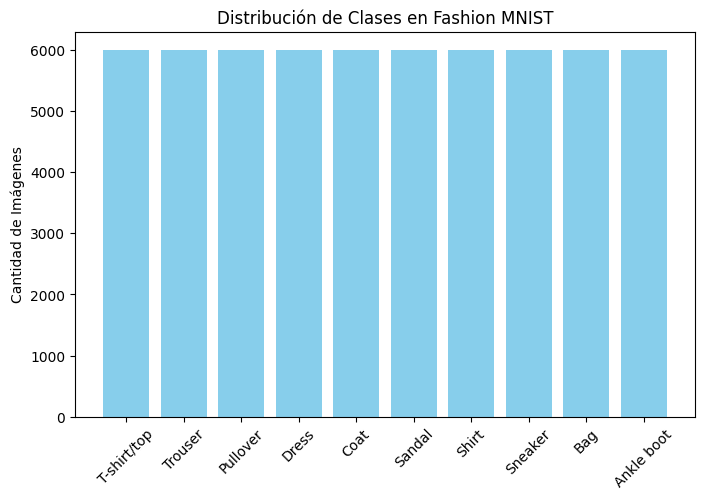

In [ ]:
# 1. Contar cuántas imágenes hay por cada categoría
unique, counts = np.unique(y_train_full, return_counts=True)

# 2. Tamaño del gráfico
plt.figure(figsize=(8, 5))

# 3. Diseño de barra usando el nombre de la prenda y su total
plt.bar(class_names, counts, color='skyblue')

# 4. Rotar etiquetas y añadir títulos
plt.xticks(rotation=45)
plt.title("Distribución de Clases en Fashion MNIST")
plt.ylabel("Cantidad de Imágenes")

# 5. Mostrar resultado
plt.show()

*JUSTIFICACIÓN Y ANÁLISIS DE CODIGO:*

- Se está utilizando np.unique con el parámetro return_counts=True para extraer la frecuencia exacta de cada una de las 10 categorías en el dataset, luego hacemos uso de la librería matplotlib para generar un gráfico de barras para poder tener otra forma de visualizar las categorías del dataset con la cantidad de datos que contienen, también se hace uso de este modo de visualización para detectar posibles sesgos en los datos de entrenamiento ya que si una red neuronal se entrena con un dataset donde una clase tiene muchas más muestras que otra el modelo va a desarrollar un sesgo hacia la clase con mayor datos.

*JUSTIFICACIÓN Y ANÁLISIS DEL GRAFICO Y RESULTADOS:*

- Se visualiza que el gráfico nos dice que los datos tienen una distribución uniforme ya que si se observa con más detalle cada una de las variables que están presentes en el dataset alcanzan exactamente el valor de 6.000 datos, sumando todos los datos de las 10 variables nos da el total de 60.000 datos los cuales son los datos que dejamos de entrenamiento, así que por eso podemos decir que esta distribución es uniforme, en resumen tenemos un dataset perfectamente balanceado.

### **1.2.2. Integridad de los datos**

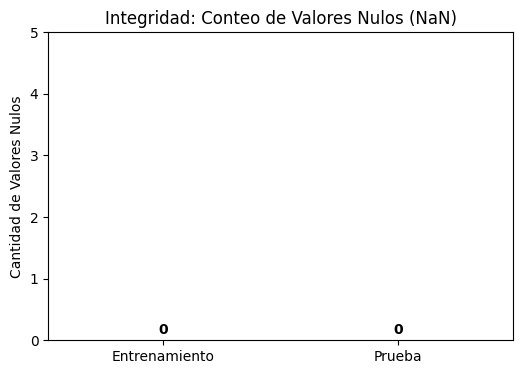

In [ ]:
def plot_missing_values(x_train, x_test):
    # Calcular cuántas imágenes tienen un valor nulo
    nulos_train = np.isnan(x_train).sum()
    nulos_test = np.isnan(x_test).sum()

    sets = ['Entrenamiento', 'Prueba']
    valores = [nulos_train, nulos_test]

    # Crear gráfico de barras
    plt.figure(figsize=(6, 4))
    bars = plt.bar(sets, valores, color=['#e74c3c', '#3498db'])

    # Añadir número sobre la barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval),
                 ha='center', fontweight='bold')

    plt.title('Integridad: Conteo de Valores Nulos (NaN)')
    plt.ylabel('Cantidad de Valores Nulos')
    plt.ylim(0, max(valores) + 2 if max(valores) > 0 else 5)
    plt.show()

# Ejecutar validación
plot_missing_values(X_train_full, X_test)

*CODIGO*

 - El código que se desarrolló realiza una inspección profunda de las variables “X_train_full” y “X_test”  utilizando función de np.isnan() para identificar posiciones de memoria que no contengan un número válido y luego los suma, luego realiza un gráfico para poder visualizar los datos para poder facilitar la interpretación de estos, por que en deep learning aprenden mediante el ajuste de pesos usando gradientes, teniendo esto en cuenta, si un valor “NAN” entra en la red, cualquier operación matemática posterior resultará en “NAN” esto se termina propagando por toda la red haciendo que la pérdida (loss) se vuelva “NAN” dejando un modelo inservible.

*GRÁFICO*

- Se observa que en el gráfico de barras tanto como la barra de datos de entrenamiento como los de prueba contienen un total de 0 datos con valor “NAN” lo que nos dice que la integridad del dataset es perfecta, no existen huecos de información en las imágenes ni en las etiquetas, al tener esta información podemos tener justificación sólida del por qué podemos omitir el paso de limpieza como por ejemplo la imputación de los datos o eliminación de las filas con datos corruptos (“NAN”) así que al tener esta información podríamos pasar directamente a la normalización y al diseño de la arquitectura de la red.

## **1.3. Tratamiento**

### **1.3.1. Visualización de muestra con mapa de calor**

Antes de aplicar cualquier técnica de preprocesamiento, es importante inspeccionar los datos en su estado original. En esta sección se visualiza una imagen del conjunto de entrenamiento como ejemplo, lo que permite entender cómo están representados los datos internamente. A través de esta visualización, se puede entender como cada imagen se relaciona a una matriz de valores y de conocer el rango de intensidad de sus píxeles.

-------------------------------------------------------
Clase de la muestra: Ankle boot (ID: 9)
-------------------------------------------------------


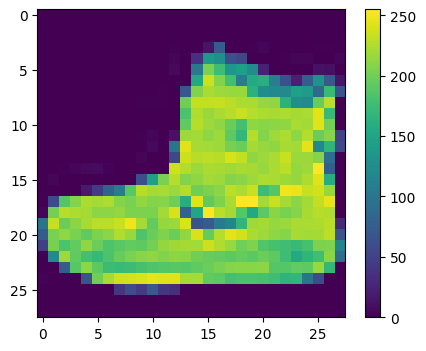

In [ ]:
# Configurar la impresión para ver la matriz completa
np.set_printoptions(linewidth=200)

print(f"-------------------------------------------------------")
print(f"Clase de la muestra: {class_names[y_train_full[0]]} (ID: {y_train_full[0]})")
print(f"-------------------------------------------------------")

# Definir tamaño del gráfico
plt.figure(figsize=(5,4))
# Mostrar la imagen
plt.imshow(X_train_full[0])
# Agregar una leyenda lateral
plt.colorbar()
# Mostrar resultado
plt.show()

**OBSERVACIÓN Y ANÁLISIS:**

- La salida es una representación numérica del objeto, ya que una imagen digital no es más que una cuadrícula de pequeños elementos llamados píxeles. Los colores que se observan en la visualización son solo una ayuda para facilitar la interpretación, ya que la máquina no "ve" colores, sino únicamente números. En este contexto, los tonos oscuros, como el púrpura, representan valores cercanos a 0, que corresponden al fondo de la imagen. Por otro lado, los tonos más claros, como el amarillo, indican valores altos cercanos a 255, los cuales forman la silueta del objeto.

- Gracias a esta variación de intensidades es posible distinguir bordes, formas y detalles de la imagen, como en este caso la bota. Esto permite entender de mejor manera cómo el modelo interpreta los datos: no como objetos visuales, sino como patrones numéricos que representan su estructura.

### **1.3.2. Representación matricial**

In [ ]:
# Mostrar la "verdad" de la computadora (los números)
print(f"-------------------------------------------------------")
print(f"Clase de la muestra: {class_names[y_train_full[0]]} (ID: {y_train_full[0]})")
print(f"-------------------------------------------------------")
print("Matriz de píxeles de la imagen:")
print(f"-------------------------------------------------------")
print(X_train_full[0])

-------------------------------------------------------
Clase de la muestra: Ankle boot (ID: 9)
-------------------------------------------------------
Matriz de píxeles de la imagen:
-------------------------------------------------------
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 

**OBSERVACIONES:**

- La imagen está representada como una matriz de números, similar a un mapa de coordenadas. Cada valor corresponde a la intensidad de un píxel, lo que permite ver con mayor claridad cómo la computadora interpreta una imagen. En este caso, los bordes de la matriz están compuestos principalmente por valores cercanos a 0, indicando la ausencia de información (fondo negro), mientras que en el centro se concentran valores más altos que forman la silueta de la bota.

- Esta distribución de valores permite identificar tanto la forma del objeto como la estructura de la imagen, que está compuesta por 28 filas y 28 columnas. A diferencia de la visualización anterior, esta representación muestra exactamente cómo la red neuronal recibe y procesa los datos.
---

**CONCLUSIÓN:** Los valores al ir de 0 a 255 dificultan el aprendizaje del modelo, ya que valores grandes pueden generar inestabilidad y hacer que el entrenamiento sea más lento o menos preciso. Por esta razón, sería necesario aplicar un escalado de los datos a un rango entre 0 y 1. Esto permite que la red neuronal entrene de forma más estable, eficiente y con mejores resultados.


### **1.3.3. Normalización de los datos**

En este paso, el código proporcionado realiza una operación simple pero muy importante, divide el valor de cada píxel por 255. Antes de esto, los píxeles estaban representados por números enteros entre 0 (negro) y 255 (blanco). Al hacer esta división, todos los valores pasan a estar en un rango entre 0.0 y 1.0

In [ ]:
# Normalizar las imágenes de entrenamiento
X_train_full = X_train_full / 255.0

# Aplicar el mismo escalado al set de prueba
X_test = X_test / 255.0

**JUSTIFICACIÓN:**

- Este cambio facilita el trabajo de la red, ya que es más eficiente procesando números pequeños que valores grandes. Además, muchas funciones de activación, como ReLU o sigmoide, funcionan mejor cuando los datos están en rangos cercanos a 0.

- También ayuda durante el entrenamiento: la red aprende ajustando sus parámetros mediante pequeños cambios (gradientes). Si los valores son muy grandes, estos cambios pueden ser demasiados bruscos y hacer que el modelo no aprenda bien. Por tanto, al poner todos los datos en el mismo rango, está no pierde tiempo lidiando con diferencias de escala y puede enfocarse directamente en aprender las formas y patrones de las imágenes.

### **1.3.4. Verificar muestras normalizadas**

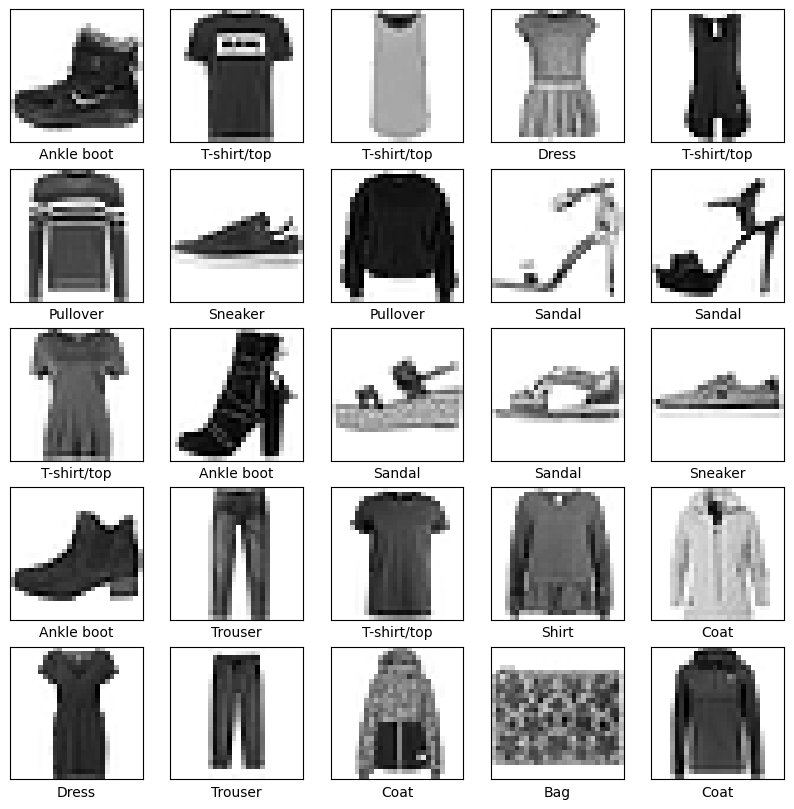

In [ ]:
# Definir el tamaño del lienzo
plt.figure(figsize=(10,10))

# Iterar sobre las primeras 25 imágenes
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Mostrar la imagen en escala de grises
    plt.imshow(X_train_full[i], cmap=plt.cm.binary)
    # Colocar el nombre de la categoría
    plt.xlabel(class_names[y_train_full[i]])

# Mostrar resultado
plt.show()

*Análisis y justificación:*

Una vez realizado el escalado lo que se está haciendo en el código es generar una matriz de visualización de los datos de entrenamiento, primero hacemos uso de plt.figure para definir un área de dibujo para que las imágenes no se vean amontonadas, después se crea un bucle (for i in range(25)) que selecciona las primeras 25 imágenes del dataset para crear una muestra representativa, paso seguido organizamos estas imágenes en cuadrículas de 5x5 luego hacemos una limpieza estética para evitar distracciones visuales para terminar mostrando las imágenes en escala de grises y colocando el nombre de la categoría debajo de cada imagen correspondiente. Se está haciendo uso de este código y decisión para poder verificar que el mapeo de “class_name” es correcto ya que si bajo la imagen de un zapato y el código de salida me diera un “T-shirt” se sabría que hay un error en la carga de etiquetas o en el orden de la lista de “class_name”, teniendo esto en cuenta si se entrena el modelo con etiquetas erróneas resulta en un modelo incapaz de generalizar, osea inservible. Por otro lado, también podemos permitirnos entender bien a que se enfrenta la red neuronal ya que al tener una visualización clara de algunas imágenes podemos darnos cuenta que hay ciertas similitudes en algunas de ellas, esto también justifica el por que el modelo podría tener dificultades para aprender. Finalmente, podemos confirmar visualmente que la resolución de 28x28 es suficiente para distinguir las imágenes y la categoría a la cual pertenecen, todos estos detalles se pudieron detectar utilizando este código y estas son las razones del por que se uso este y la toma de desiciones.


# **Fase 2: Configuración de la red neuronal**

## **2.1. Configuración de capas**

En primera instancia estaremos creando un modelo secuencial, el cual significa que las capas iran una tras otra. Esto lo haremos con la funcion Sequential de Keras.

In [ ]:
# Definir un modelo secuencial
model = keras.models.Sequential([

    # Definir la forma de entrada de las imágenes
    keras.layers.Input(shape=(28,28)),

    # Convertir cada imagen en un vector de 784 valores
    keras.layers.Flatten(),

    # Capa densa con 128 neuronas y función de activación ReLU
    keras.layers.Dense(128, activation='relu'),

    # Capa de salida con 10 neuronas,
    # Softmax convierte los valores en probabilidades
    keras.layers.Dense(10, activation='softmax')
])

- En nuestro primer código estamos transformando cada imagen de 28x28 pixeles en un vector lineal de 784 valores (28x28). Esto lo hacemos de manera obligatoria porque más abajo estaremos usando capas “Dense”, la cual quiere decir que es una capa densa o conectada, en palabras simples, cada una de las 128 neuronas, estará conectada con todos los 784 píxeles. Cabe destacar que Dense solo acepta datos unidimensionales (vector lineal).

- Luego tenemos una capa oculta con 128 neuronas, las cuales consideramos es un tamaño equilibrado para extraer patrones de prendas sin tener un exceso de costo computacional, haya overfitting o aprenda poco por falta de neuronas. Seguidamente hacemos la activación con la función ReLU, la cual nos ayuda a poder introducir no linealidad, esto nos sirve para poder aprender formas complejas, es decir, formas que no son tan simples como una línea vertical, horizontal y ya, sino por ejemplo la forma de una polera, la cual tiene muchas curvas, líneas, etc. Esto ayudará a que la red se entrene más rápido. Cabe destacar que esto lo hace tomando los resultados de las sumas y multiplicaciones que se hicieron anteriormente en la red, en caso de que el resultado sea negativo, lo dejará en 0 y si es positivo, lo dejará tal cual.

- Posteriormente tenemos la capa de salida con Softmax, en donde configuramos 10 neuronas ya que el dataset tiene 10 categorías de ropa y es obligatorio usar la misma cantidad de neuronas como categorías tenga nuestro set de datos. La función Softmax es muy importante porque nos transforma las salidas numéricas en probabilidades, esto es para saber qué certeza tiene la red con cada categoría, es decir, que tan bien predice que es una polera, una zapatilla, un pantalón, etc. Softmax toma los resultados crudos de las 10 neuronas y los convierte en porcentajes que suman 100%. Dice algo así como: “Estoy 80% seguro que es una chaqueta, 10% de que es una polera y otro 10% de que es una camisa”. En pocas palabras la capa de salida nos ayuda a recolectar información procesada por la capa anterior y entregar la predicción final.


## **2.2. Definición inicial de hiperparámetros**

In [ ]:
# Número de épocas
epochs = 10

# Tamaño del batch
batch_size = 32

# Tasa de aprendizaje
learning_rate = 0.001

**JUSTIFICACIÓN:**

- **Época:** La elección de este valor como configuración inicial responde a la necesidad de proporcionar al modelo una cantidad suficiente de ciclos de aprendizaje para identificar patrones relevantes en las imágenes, como formas, bordes y texturas de las prendas. Siendo importante entender el efecto que tiene entrenar con muy pocas épocas, en donde el modelo no alcanza a aprender adecuadamente, ya que no tiene suficientes oportunidades para corregir sus errores, por lo que solo "observa" los datos sin lograr captar sus patrones. Por el contrario, con demasiadas épocas, el modelo puede comenzar a aprender incluso el ruido o detalles irrelevantes del dataset, lo que afectaría su desempeño al enfrentrarse a datos nuevos. Por esta razón, definir un valor intermedio como punto de partida permite lograr un equilibrio entre aprendizaje y generalización. Por lo que utilizar 10 épocas proporciona una base inicial estable y eficiente, permitiendo observar resultados en un tiempo razonable y facilitar la posterior realización de ajustes en función del comportamiento del modelo.

---
- **Tamaño del batch:** Este valor inicial permite procesar varias imágenes al mismo tiempo, logrando que la red actualice sus pesos de forma frecuente, pero con suficiente información en cada paso. Si se trabajará con un batch muy pequeño, como 2 imágenes se generaría un aprendizaje inestable, haciendo que el modelo tome decisiones con muy poca información en cada actualización. En cambio, si fuera uno demasiado grande esté consumiría mucha memoria, provocando un entrenamiento más lento o menos eficiente. Por lo que, el tamaño definido de 32 imágenes por batch es un buen inicio para que la red pueda observar suficiente variedad de ejemplos en cada paso sin sobrecargar el sistema.

---
- **Tasa de aprendizaje:** Actúa como un regulador de confianza y precisión guiando al modelo cada vez que este comete un error al clasificar las prendas, calculando la dirección y la fuerza con la que se deben ajustar los parámetros para corregir el rumbo. Si se usara una tasa de 1.0, el modelo al estudiar la categoría de calzado, podría identificar que tienen cordones y asumir apresudaramente que esa es la única característica importante. Pero, si en el siguiente grupo de imágenes aparece una sandalia, el modelo corregiría rápido y borraría lo aprendido sobre los cordones para priorizar las tiras de la sandalia. Al aprender de esta forma el modelo "sobrecorrige" y olvida el conocimiento previo, lo que impide que logre una visión general y estable de lo que es un zapato. En cambio con una tasa de 0.0001, si la red ha visto mayoritariamente camisas y de pronto aparece un vestido, el ajuste sería tan insignificante que el modelo ignoraría la nueva realidad, tratándola como un error o ruido sin importancia. Por lo tanto, la elección del valor de 0.001 se encuentra en un punto de equilibrio, ya que si el modelo ve muchas camisas y luego algunos vestidos, no borrará lo aprendido sobre las mangas de las camisas, simplemente ajustará su conocimiento de a poco para integrar las características de los vestidos.







## **2.3. Resumen de la estructura**

Permite visualizar la estrutura completa del modelo. Esta herramienta muestra las capas que componen la red neuronal, los parámetros entrenables y la forma de los datos en cada etapa. Esto es fundamental para verificar que el modelo ha sido construido correctamente antes de iniciar el proceso de entrenamiento.

In [ ]:
# Mostrar resumen del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## **2.4. Configuración del entrenamiento del modelo**

Se configura el modelo para su entrenamiento utilizando el optimizador ADAM con su tasa de aprendizaje definida previamente, también se define la función de pérdida ya que nos enfrentamos a un problema de clasificacion multiclase, además se utiliza accuracy como métrica de evaluación para medir el porcentaje de aciertos del modelo durante su entrenamiento.

In [ ]:
model.compile(

    # Optimizador Adam
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),

    # Función de pérdida
    loss='sparse_categorical_crossentropy',

    # Métrica de evaluación
    metrics=['accuracy']
)

## **2.5. Entrenamiento inicial del modelo**

In [ ]:
# Entrenar el modelo usando los datos de entrenamiento
history = model.fit(

    # Datos de entrada y sus etiquetas
    X_train_full, y_train_full,

    # Número de épocas
    epochs=epochs,

    # Tamaño del batch
    batch_size=batch_size,

    # Separar el 20% de datos para validación durante el entrenamiento
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8185 - loss: 0.5185 - val_accuracy: 0.8553 - val_loss: 0.4099
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8611 - loss: 0.3878 - val_accuracy: 0.8583 - val_loss: 0.3928
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8743 - loss: 0.3479 - val_accuracy: 0.8700 - val_loss: 0.3601
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8819 - loss: 0.3211 - val_accuracy: 0.8766 - val_loss: 0.3437
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8888 - loss: 0.3021 - val_accuracy: 0.8796 - val_loss: 0.3349
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8924 - loss: 0.2892 - val_accuracy: 0.8834 - val_loss: 0.3192
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8974 - loss: 0.2766 - val_accuracy: 0.8827 - val_loss: 0.3216
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9017 - loss: 0.2645 - 

## **2.6. Visualización de resultados**

### **2.6.1. Gráfico de evolución del accuracy durante el train**

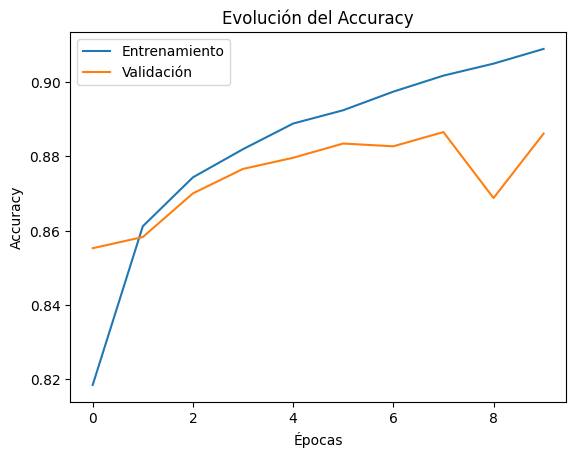

In [ ]:
# Accuracy del conjunto de entrenamiento
plt.plot(history.history['accuracy'], label='Entrenamiento')

# Accuracy del conjunto de validación
plt.plot(history.history['val_accuracy'], label='Validación')

# Etiqueta del eje X
plt.xlabel('Épocas')

# Etiqueta del eje Y
plt.ylabel('Accuracy')

# Mostrar leyenda para diferenciar curvas
plt.legend()

# Título del gráfico
plt.title('Evolución del Accuracy')

# Mostrar gráfico
plt.show()

### **2.6.2. Gráfico de evolución de la función de pérdida durante el train**

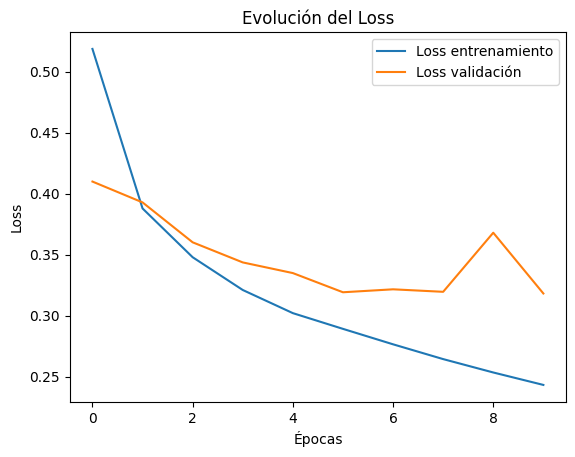

In [ ]:
# Loss del conjunto de entrenamiento
plt.plot(history.history['loss'], label='Loss entrenamiento')

# Loss del conjunto de validación
plt.plot(history.history['val_loss'], label='Loss validación')

# Etiqueta del eje X
plt.xlabel('Épocas')

# Etiqueta del eje Y
plt.ylabel('Loss')

# Mostrar leyenda para diferenciar curvas
plt.legend()

# Título del gráfico
plt.title('Evolución del Loss')

# Mostrar gráfico
plt.show()

# **Fase 3: Funciones core**

## **3.1. Comparación de rendimiento entre funciones de activación**

In [ ]:
# Diccionario para definir las funciones de activación
activations = {
    'relu':     'relu',
    'sigmoid':  'sigmoid',
}

# Diccionario vacío para almacenar los resultados de cada train
histories = {}

# Iniciar bucle para probar cada función
for name, act in activations.items():
    tf.random.set_seed(40)

    # Definir la arquitectura del modelo
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation=act),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Configurar el motor de aprendizaje
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenar el modelo y guardar el progreso
    history = model.fit(
        X_train_full, y_train_full,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    # Almacenar el historial de entrenamiento
    histories[name] = history

## **3.2. Visualización de resultados**

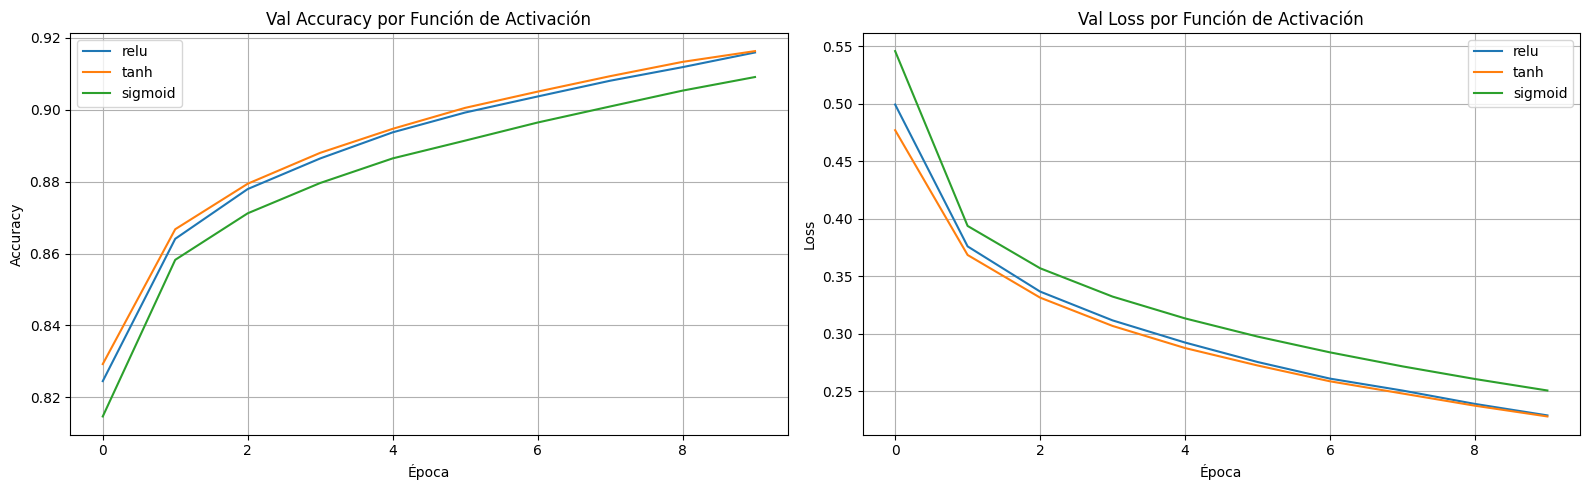

------------------------------
Resumen de resultados:
------------------------------
Función RELU:
- Precisión Final: 91.60%
- Pérdida Final:   0.2288
------------------------------
Función TANH:
- Precisión Final: 91.64%
- Pérdida Final:   0.2279
------------------------------
Función SIGMOID:
- Precisión Final: 90.91%
- Pérdida Final:   0.2505
------------------------------


In [ ]:
# Crear figura para mostrar gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Iterar sobre los resultados guardados de cada función
for name, history in histories.items():
    # Obtener las claves del historial
    keys = list(history.history.keys())
    acc_key = 'accuracy' if 'accuracy' in keys else 'val_acc'

    # Dibujar la curva de precisión en el primer gráfico
    axes[0].plot(history.history[acc_key], label=name)
    # Dibujar la curva de pérdida en el segundo gráfico
    axes[1].plot(history.history['loss'], label=name)

# Configurar el gráfico de precisión
axes[0].set_title('Val Accuracy por Función de Activación')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
# Mostrar el cuadro con los nombres
axes[0].legend()
# Añadir cuadrícula
axes[0].grid(True)

# Configurar el gráfico de pérdida
axes[1].set_title('Val Loss por Función de Activación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Ajustar el espacio entre los gráficos
plt.tight_layout()
# Mostrar resultado
plt.show()

print("-" * 30)
print("Resumen de resultados:")
# Iterar a través de cada función
for name, history in histories.items():
    # Extraer el último valor de la lista del historial
    final_acc = history.history['accuracy'][-1] if 'accuracy' in history.history else history.history['val_acc'][-1]
    final_loss = history.history['loss'][-1]

    print("-" * 30)
    print(f"Función {name.upper()}:")
    print(f"- Precisión Final: {final_acc * 100:.2f}%")
    print(f"- Pérdida Final:   {final_loss:.4f}")
print("-" * 30)

Entrenando modelo por 5 épocas...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo por 10 épocas...
Entrenando modelo por 15 épocas...
Entrenando modelo por 20 épocas...


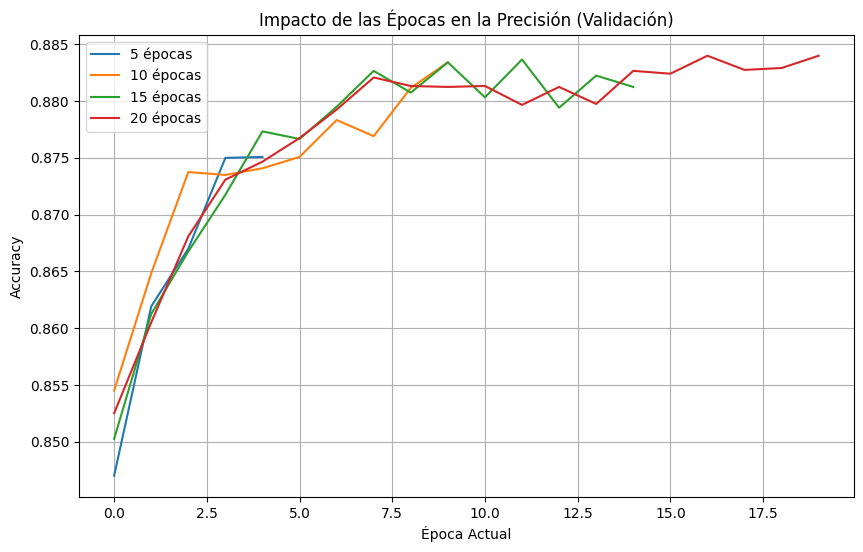

In [ ]:
# Definimos las variantes de épocas que queremos probar
epocas_a_probar = [5, 10, 15, 20]
historiales_epocas = {}

for e in epocas_a_probar:
    print(f"Entrenando modelo por {e} épocas...")

    # Re-creamos el modelo en cada iteración para que empiece de cero
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[28,28]),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenamos con la cantidad de épocas actual (e)
    history = model.fit(
        X_train_full, y_train_full,
        epochs=e,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # Guardamos el historial para graficar
    historiales_epocas[e] = history

# --- GRÁFICO COMPARATIVO ---
plt.figure(figsize=(10, 6))

for e, hist in historiales_epocas.items():
    plt.plot(hist.history['val_accuracy'], label=f'{e} épocas')

plt.title('Impacto de las Épocas en la Precisión (Validación)')
plt.xlabel('Época Actual')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## **Fase 4: Optimización** (Estabilizacion del modelo y mitigacion del overfiting mediante dropout y regulizacion.)

In [ ]:
# Definir modelo secuencial
model = keras.models.Sequential([

    # Capa de entrada que recibe imágenes
    keras.layers.Input(shape=(28,28)),

    # Convierte la imagen en un vector
    keras.layers.Flatten(),

    # Capa oculta con 128 neuronas y función de activación
    keras.layers.Dense(128, activation='relu'),

    # Capa Dropout que ayuda a reducir el sobreajuste
    keras.layers.Dropout(0.4),

    # Capa de salida con 10 neuronas y Softmax que convierte los valores en probabilidades
    keras.layers.Dense(10, activation='softmax')
])

**JUSTIFICACIÓN:** Siguiendo lo trabajado en la fase anterior, se usa la función de keras para crear un modelo secuencial, luego se crea la entrada de las imágenes en píxeles de 28x28, posteriormente con flatten se transforman las imágenes en un vector unidimensional de 784 valores (28x28). Después, procedemos con la función de activación ReLU, con la cuál podemos incorporar no linealidad para que el modelo pueda distinguir no solo líneas horizontales o verticales, sino también léneas complejas de las diferentes prendas del data set. Luego, pasamos a la capa de Dropout, la cuál desactiva el 40% de las neuronas para que el modelo no memorice ni dependa de un píxel de los 784 para poder trabajar bien. Finalmente, se trabaja con Softmax para poder ver los valores en probabilidad. Lo que hace es básicamente darnos los resultados obtenidos luego de pasar por todas las capas y fases anteriores. Está nos dirá por ejemplo: "Estoy 90% seguro que es una camisa y 10% que es una polera".

In [ ]:
# Número de épocas
epochs = 18

# Tamaño del batch
batch_size = 128

# Tasa de aprendizaje
learning_rate = 0.001

- El modelo verá el set de datos completo 18 veces, esto lo hace pasando por las 60.000 imágenes del data set. Luego, estamos configurando que el modelo cada 128 imágenes ajustará su error, es decir, verá 128 imágenes y con el optimizador Adam hará una actualización de aprendizaje.

In [ ]:
# Mostrar resumen del modelo
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    # Optimizador Adam
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    # Función de pérdida
    loss='sparse_categorical_crossentropy',
    # Métrica de evaluación
    metrics=['accuracy']
)

**JUSTIFICACIÓN:** Tenemos el optimizador Adam, el cuál nos ayuda a cambiar las velocidades de aprendizaje, según el estándar industrial lo mejor es usar saltos de 0.001, esto ayuda a que no haya saltos grandes. La función loss nos devuelve que tan grande fue el error, entonces el optimizador vuelve atrás y actualiza los pesos (importancia) de cada neurona para que en un futuro se equivoque menos. Se está usando loss='sparse_categorical_crossentropy' para ver que tan equivocadas están las probabilidades que predijo la red en comparación con la respuesta real, además, se usa sparse porque las respuestas correctas que le demos a la red serán números enteros, no respuestas transformadas. Finalmente, estaremos usando la métrica de accuracy para medir el porcentaje de predicciones correctas. Se usará esta métrica porque el dataset tiene 6.000 ejemplos en cada categoría, lo que hace que este balanceado, por lo que no tendrá un sesgo hacia uno u otro.

In [ ]:
history = model.fit(
    X_train_full, y_train_full,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7623 - loss: 0.6822 - val_accuracy: 0.8405 - val_loss: 0.4506
Epoch 2/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8349 - loss: 0.4717 - val_accuracy: 0.8545 - val_loss: 0.3986
Epoch 3/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8460 - loss: 0.4280 - val_accuracy: 0.8610 - val_loss: 0.3774
Epoch 4/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8554 - loss: 0.4047 - val_accuracy: 0.8687 - val_loss: 0.3599
Epoch 5/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8613 - loss: 0.3864 - val_accuracy: 0.8722 - val_loss: 0.3521
Epoch 6/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8650 - loss: 0.3732 - val_accuracy: 0.8747 - val_loss: 0.3470
Epoch 7/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8703 - loss: 0.3599 - val_accuracy: 0.8762 - val_loss: 0.3398
Epoch 8/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8739 - loss: 0.3489 - val_accuracy: 0.

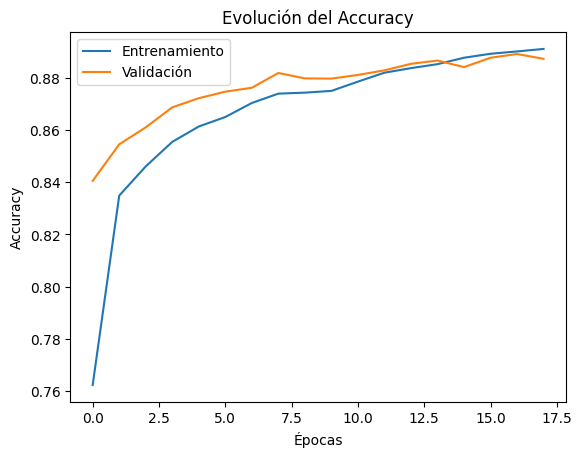

In [ ]:
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Evolución del Accuracy')
plt.show()

*Codigo*

- Se está haciendo uso de la librería matplotlib para extraer los datos que están almacenados en el objeto “history”, estamos haciendo uso de esta código para poder ver con mejor claridad el aprendizaje de la red neuronal ya que sin este gráfico solo veríamos números por consola así que con el uso del gráfico se puede facilitar visualizar la tendencia, es una forma rápida de poder identificar si el modelo está aprendiendo realmente con los datos de entrenamiento, si solamente está memorizando los datos o ver en qué época deja de mejorar ayudándonos a decidir si es que se necesitan más épocas de entrenamiento o si se debe detener antes y por ultima opcion cambiar la arquitectura de la red neuronal.

*Grafico*

- Podemos ver que en el gráfico ambas curvas tanto la de entrenamiento(azul) y la de validación(naranja) tienen una pendiente positiva, esto se puede considerar como excelente ya que indica que el modelo está aprendiendo a clasificar los datos a medida que pasan las épocas si observamos con más cuidado podemos ver que cerca de la época 2 la precisión de entrenamiento supera a la de validación, esto es normal ya que estos son los puntos en donde el modelo empieza a volverse un experto en los datos que ve constantemente, otra de las observaciones que podemos ver es que la curva de validación(naranja) sube de forma constante hasta la época 6 en donde alcanza los (0.88) luego tiene un pequeño bache en la época 8 y vuelve a subir, esto nos está diciendo que existe una estabilidad pequeña pero sigue siendo una tendencia “sana”, por último podemos ver al final de las 10 épocas que existe una diferencia de aproximadamente un 2% entre el entrenamiento (0.91) y la validación(0.89).


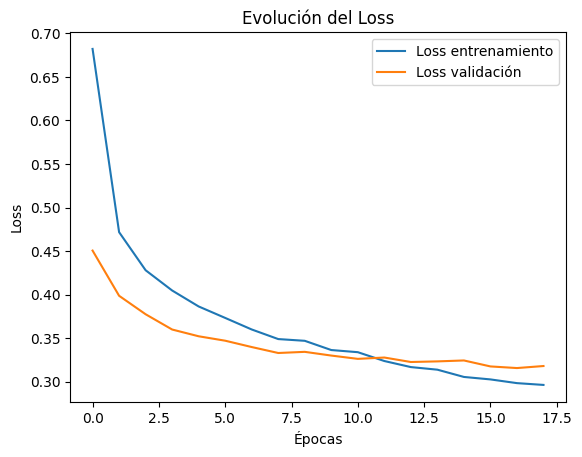

In [ ]:
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Evolución del Loss')
plt.show()

*Codigo*

- El código lo que está haciendo es un gráfico de la función de pérdida de “categorical_crossentropy” calculada al final de cada época, por que el optimizador que se está utilizando el cual es Adam trabaja solamente para reducir ese número,  aparte también debemos tener en cuenta que un modelo puede tener un buen accuracy pero teniendo un loss alto estaría acertando con dificultad o con dudas haciendo que el modelo se equivoque en un acierto del cual estaba seguro, dejando estancado el aprendizaje de la red.

*Gradico*

- Se puede observar que la curva de entrenamiento(azul) baja de forma muy suave desde 0.52 hasta aproximadamente 0.24 esta confirma que el optimizador está ajustando los pesos correctamente, alrededor de la primera época el error de entrenamiento se vuelve(azul) menor que el de validación(naranja) aquí podemos ver que el modelo empieza a ajustarse a los datos de entrenamiento(azul), por otro lado podemos ver que a diferencia de la curva de entrenamiento(azul), la de validación(naranja) empieza a ir un poco recta a partir de la época 4 y entre la época 7 y 9 el error de validación casi no baja, por último vemos que al final de las 10 épocas existe una diferencia notable entre las dos líneas(entrenamiento y aprendizaje), mientras el error en entrenamiento sigue cayendo con fuerza, el de validación parece haber encontrado su límite.
podemos decir que esta gráfica nos está mostrando un comienzo de sobreajuste(overfitting) ya que al ver el comportamiento de ambas líneas el modelo está aprendiendo patrones que solamente existen en el set de datos de entrenamiento y no están aplicando en la línea de validación.


## **Fase 5: Evaluación** (Calculo matematico e interpretacion de Accuracy, precision, recall y f1-score)

#Evaluacion del modelo, ademas de metris de confusión

en esta parte es donde se evañua la presición del modelo y su perdida, esto siguiendo los siguientes pasos

primero obtenesmos la presición y perdida al termino de la ultima epoca

en y_prod se guarda la probabilidad  que le da modelo a cada una de las 10000 imagenes en base a las 10 clases dispoibles. esto atraves del metodo predict que tiene la red este metodo recorre los 784 pixeles que tiene cada imagen y en un array almacena la probabiidad que tiene esa imagen de ser cada una de las clases

Y_pred_clases en esta variable se almacena por cada imagen la probabilidad mas alta obtenida por cada clase, esto se logra con numpy np.argmax y su metodo argmax, el cual recibe los valores(en el paso anterior los resultados quedarom en un array) y con el parametro axis = 1 le decimos que busque por fila, en caso de ser 0 buscaria por cada columna

el siguiente paso es imprimir las metricas mas importantes de la red, para esto se uso  sklearn.metrics , esta es una libreria univerzal para obtener este tipo de metricas, en concreto se uso 2 metodos classification_report, confusion_matrix

con classification_report se obtiene precision    recall  f1-score   support, para esto es necesario pasarle entre los parentesis, los valores reales de testeo, en este caso puede ser y_test, o y_true (ya que ambos contienen las imagenes), el segundo parametro son las probabilidad que le dio la red a cada imagen de ser una de las 10 clases en este caso la variable a pasar es Y_pred_clases, y el tercer y ultimo parametro son las clases almacenadas en class_names

el siguiente paso es obtener los valores de confusion esto con el metodo confusion_matrix el cual recibe como paramtro y_test o y_true(imagenes de teste0) y el segundo parametro es la probabilidad almacenada en Y_pred_clases

el ultimo paso es visualizar la matriz esto a traves de matplotlib

Accuracy: 87.85%
Pérdida: 0.3503
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.82      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.77      0.78      1000
       Dress       0.86      0.90      0.88      1000
        Coat       0.74      0.88      0.80      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.72      0.62      0.66      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



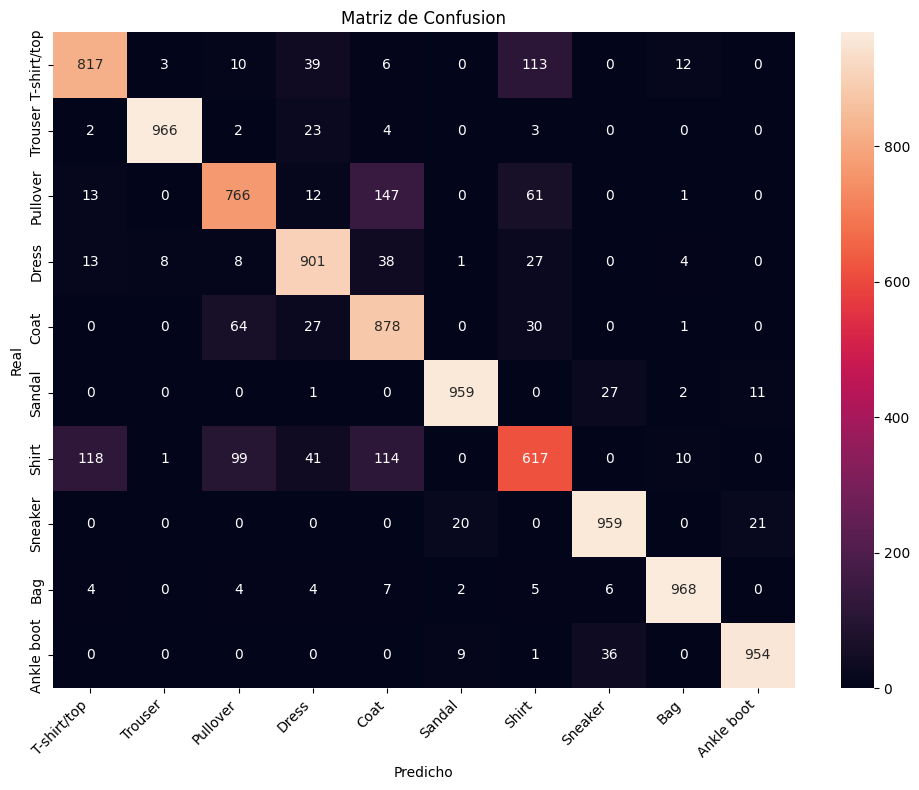

In [ ]:
# evaluamos el modelo
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Pérdida: {loss:.4f}")

# metricas completas por clase
Y_pred = model.predict(X_test, verbose=0)
Y_pred_clases = np.argmax(Y_pred, axis=1)
Y_true = y_test

print(classification_report(Y_true, Y_pred_clases, target_names=class_names))


# matriz de confusion
cm = confusion_matrix(Y_true, Y_pred_clases)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Analisis de modelo*

Se puede observar que los resultados entregan un accuracy de 87.85% y una perdida de 0.3503% lo que esto nos indica que el modelo está seguro de sus predicciones pero el valor de pérdida que tenemos nos está diciendo que aún existe algún ajuste que pueda mejorar estos resultados, una de las clases más problemáticas Shirt (camisa) con un valor 0.66, esta se confunde 118 veces con la clase T-shirt/Top(camiseta), también se confunde 114 veces con la clase Coat(Abrigo) y se confunde 99 veces con la clase Pullover(Suéter), por otro lado también podemos ver que la clase Pullover(Suéter) se clasifica mal y las confunde como clase Coat(Abrigo) una cantidad de 147 veces, esto si nos ponemos a pensar igual es lógico ya que con las dimensiones tan chicas de 28x28 el modelo no logra diferenciar los detalles de cada una de estas clases ya que algunas tienen una silueta bastante similar y en este caso el modelo está priorizando la forma y no las texturas es por esta razón que al modelo se le hace muy difícil reconocer detalles como por ejemplo los botones, cierres, cuellos, etc.
en conclusiones podríamos decir que el modelo ser bueno teniendo un 87.85% de accuracy y con el total de perdida que serian 0.35% no parece haber señales de sobre ajustes(overfitting) en grande escala, el valor de perdida es mas por que el modelo tiene dudas constantemente al momento de diferenciar clases que sean superiores o de las partes del torso(camisas, camisetas, abrigos, sweaters) dejándonos como resultado un punto débil en el modelo que nos dice que el modelo confunde 4 de cada 10 camisas como otras prendas(camisas, camisetas, abrigos, sweaters)  


## **Conclusión**